<a href="https://colab.research.google.com/github/parthdabhi5195/YT-AI/blob/main/YT_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!cp "/content/drive/MyDrive/Colab Notebooks/stories.jsonl" /content/stories.jsonl

Mounted at /content/drive


In [ ]:
import os

DATA_PATH = "/content/stories.jsonl"
OUT_DIR = "slm_out"
LIMIT = 0

os.makedirs(OUT_DIR, exist_ok=True) # OUT_DIR must exist before anything writes into it

# slm_out lives on the Colab VM and is wiped the moment the session ends, so mirror
# the two files worth keeping to Drive. Set DRIVE_BACKUP = None to turn this off.
DRIVE_BACKUP = "/content/drive/MyDrive/yt-ai-slm"
BACKUP_EVERY = 5 # back up the resume checkpoint every Nth eval (it is ~614 MB, so not every time)
if DRIVE_BACKUP: os.makedirs(DRIVE_BACKUP, exist_ok=True)


In [ ]:
!pip3 install tiktoken

In [ ]:
!pip3 install datasets

In [ ]:
!pip3 install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 23.7 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.8.5
    Uninstalling datasets-4.8.5:
      Successfully uninstalled datasets-4.8.5


## STEP 1: Importing Dataset


In [ ]:

from datasets import load_dataset, Features, Value, Sequence

# needed due to schema change partway through file. Changes starts at line 1433252 in stories.jsonl
features = Features({
    "id": Value("string"),
    "story_text": Value("large_string"),
    "word_count": Value("int64"),
    "prompt_sha256": Value("string"),
    "source_template_id": Value("string"),
    "chunk": Value("string"),
    "setting": Value("string"),
    "occupation": Value("string"),
    "relationship_dynamic": Value("string"),
    "incident_seed": Value("string"),
    "hook_style": Value("string"),
    "character_names": Sequence(Value("string")),
    "source_title": Value("string"),
    "source_channel": Value("string"),
    "source_views": Value("int64"),
    "salvaged_from": Sequence(Value("string")),   # missing in the first 1.43M rows
})

ds = load_dataset("json", data_files=DATA_PATH, split="train", features=features)

if LIMIT:
    ds = ds.select(range(LIMIT))

ds = ds.train_test_split(test_size=0.01, seed=42, shuffle=True)
ds["val"] = ds.pop("test")      # two splits: train and val

print(ds)

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'story_text', 'word_count', 'prompt_sha256', 'source_template_id', 'chunk', 'setting', 'occupation', 'relationship_dynamic', 'incident_seed', 'hook_style', 'character_names', 'source_title', 'source_channel', 'source_views', 'salvaged_from'],
        num_rows: 2417196
    })
    val: Dataset({
        features: ['id', 'story_text', 'word_count', 'prompt_sha256', 'source_template_id', 'chunk', 'setting', 'occupation', 'relationship_dynamic', 'incident_seed', 'hook_style', 'character_names', 'source_title', 'source_channel', 'source_views', 'salvaged_from'],
        num_rows: 24417
    })
})


## STEP 2: Tokenize Dataset

(1) Tokenize the story dataset into tokenIDs

(2) Append <|endoftext|> after each story

(3) Create a file called "train.bin", "val.bin", "test.bin" to store all tokenIDs from the entire dataset. This is to increase speed (byte files don't need to parse characters like they have to in JSON), decrease storage size, and allow memory-mapping (letting us work with files larger than our RAM size by retrieving only active chunks).
(4) Make sure tokenIDs are stored to disk rather than RAM.

In [ ]:
import tiktoken
import numpy as np
from tqdm.auto import tqdm # progress bar

enc = tiktoken.get_encoding("gpt2")
eot_id = enc.eot_token # <|endoftext|>
vocab_size = enc.n_vocab # from GPT2

def process(example):
    ids = enc.encode_ordinary(example['story_text']) # encode_ordinary ignores special tokens
    ids.append(eot_id)
    out = {'ids' : ids, 'len' : len(ids)} # {'ids' : list, len : int}
    return out

# Parallel Tokenization
if not os.path.exists(f"{OUT_DIR}/train.bin"):
    # ds.map() writes tokenIds to Array cache on disk, not RAM
    tokenized = ds.map (
        process,
        remove_columns=ds['train'].column_names, # remove all columns from output
        desc="tokenizing the splits", #tqdm labelled display
        num_proc=8 # applies the process function on every row in dataset across 8 threads
    )

    for split, dset in tokenized.items():
        # setting to uint64 to optimize storage. GPT2 vocab size is 50,257 so, 2^16 (65,535), every tokenID fits comfortably within this range
        arr_len = np.sum(dset['len'], dtype=np.uint64) # adding up the token counts in all rows of particular split to calculate exact number of tokens needed for array
        filename = f'{OUT_DIR}/{split}.bin'
        dtype = np.uint16 # stores tokenIDs as unsigned 16-bit values. Halves disk space compared to 32-bit integers
        arr = np.memmap(filename, dtype=dtype, mode='w+', shape=(arr_len,)) # allocates arr_len size memory mapped array in disk rather than in RAM
        total_batches = min(1024, len(dset)) # a split with fewer rows than shards can't be sharded. Used for safety with the limit flag

        idx = 0
        for batch_idx in tqdm(range(total_batches), desc=f'writing {filename}'):
            # batch samples together for faster write
            batch = dset.shard(num_shards = total_batches, index=batch_idx, contiguous=True).with_format('numpy')
            arr_batch = np.concatenate(batch['ids']) # flatten a list of individual stories into a 1D sequence since binary file is 1D
            # write into memmap
            arr[idx : idx + len(arr_batch)] = arr_batch # copy entire flattened block
            idx += len(arr_batch)
        arr.flush() # write to disk after all batches are processed

# Read back from the files, so this is right whether or not the block above ran.
train_tokens = os.path.getsize(f"{OUT_DIR}/train.bin") // 2 # used for training config
val_tokens   = os.path.getsize(f"{OUT_DIR}/val.bin") // 2
print(f"train.bin: {train_tokens:,} tokens")
print(f"val.bin:   {val_tokens:,} tokens")

tokenizing the splits (num_proc=8):   0%|          | 0/2417196 [00:00<?, ? examples/s]

tokenizing the splits (num_proc=8):   0%|          | 0/24417 [00:00<?, ? examples/s]

writing slm_out/train.bin:   0%|          | 0/1024 [00:00<?, ?it/s]

writing slm_out/val.bin:   0%|          | 0/1024 [00:00<?, ?it/s]

train.bin: 838,638,935 tokens
val.bin:   8,464,873 tokens


## STEP 3: Creating Input-Output Batches for Dataset

In [ ]:
import torch

if torch.cuda.is_available():
    device = "cuda" # nvidia gpu
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = "mps" # apple silicon
else:
    device = "cpu" # sadly cpu

device_type = device

def get_batch(split):
    data = np.memmap(f"{OUT_DIR}/{split}.bin", dtype=np.uint16, mode="r") # reading from disk without loading entire dataset into RAM
    ix = torch.randint(len(data) - block_size - 1, (batch_size,)) # 1D tensor that randomly selects indices within the maximum index
    x = torch.stack([torch.from_numpy((data[i : i + block_size]).astype(np.int64)) for i in ix]) # assemble current input batch. embedding layers strictly require int64. each slice is a numpy array of type int64
    y = torch.stack([torch.from_numpy((data[i + 1 : i + block_size + 1]).astype(np.int64)) for i in ix]) # assemble associated correct answer
    if device_type == "cuda":
        # move tensors x, y from CPU memory to GPU memory and prevent OS from swapping out to disk (locked into RAM)
        # non_blocking creates asynchronous calls so CPU doesn't wait for GPU to finish processing and can do things like next batch preparation
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        # if using CPU, default to normal config
        x, y = x.to(device), y.to(device)

    return x, y

print(f"device: {device}")

device: cuda


## STEP 4: Defining YT-AI architecture

In [ ]:
import torch # base PyTorch library
import torch.nn as nn # neural network module (ex. nn.Linear, nn.Embedding)
import torch.nn.functional as F # F.layer_norm, F.softmax, F.cross_entropy
import math # square root scaling
from dataclasses import dataclass # structured data containers
import numpy as np
from tqdm.auto import tqdm # progress bar generator
from contextlib import nullcontext # placeholder context manager
import os # filesystem operations

# Use LayerNorm instead of BatchNorm. LayerNorm is used in NLP when sentences come in variable length sequences.
# [5, 2, 7, 4, 1, 3]
# [8, 1, 6, X, X, X] why average over dimension 0 when columns near the end are mostly padding?
# [3, 9, X, X, X, X]
# [6, 4, 2, 7, 5, X]
class LayerNorm(nn.Module): # override nn.Module's __init__() and forward()
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim)) # gamma
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None # beta
    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5) # gamma * (standarized feature row) + beta

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0 # ensures embedding dimension cleanly divides across all heads of attention
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias) # (768, 3 * 768). 768 inputs, and 3x to later split Q, K, V
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias) # (768, 768) linear layer that mixes head outputs back into residual stream
        # takes percentage of random elements in attention affinity matrix (QK / sqrt(dk)) and sets to 0 during training (not inference)
        self.attn_dropout = nn.Dropout(config.dropout)# prevents model from relying heavily on single token-to-token relationships. Forces tokens to learn features from other tokens. Prevents overfitting
        # takes output vector y (after linear projection) but before it gets added to residual stream, and randomly 0s channel dimensions
        self.resid_droupout = nn.Dropout(config.dropout) # encourages model to not heavily rely on entire attention output and preserve more information through residual path
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        # prevents writing large (T, T) matrix into slow GPU VRAM. Rather, it creates smaller blocks inside fast SRAM
        self.flash = hasattr(F, 'scaled_dot_product_attention') # True or False flag to check if user's version supports FlashAttention (speeds attention while using less GPU memory)
        # create masked attention manually if not self.flash
        if not self.flash:
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size)).view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # x will be 3D
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2) # slices the 3 * C projection into individual Q, K, V tensors (B, T, C)

        # reshape each tensor to (B, n_head, T, dk) to align each attention head as independent matrix batch
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        if self.flash:
            # faster way to implement the else condition
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None, dropout_p=self.attn_dropout.p if self.training else 0.0, is_causal=True)
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1))) # (B, n, T, dk) @ (B, n, dk, T) = (B, n, T, T)
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf')) # overwrites future tokens with -inf (necessary for softmax)
            att = F.softmax(att, dim=-1) # (B, n, T, T)
            att = self.attn_dropout(att) # (B, n, T, T)
            y = att @ v # (B, n, T, T) @ (B, n, T, dk) = (B, n, T, dk)

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_droupout(self.c_proj(y))
        return y

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias) # fully connected linear layer to 4x C dimension to facilitate deeper interactions
        self.gelu = nn.GELU() # Gaussian Error Linear Unit (nonlinearity like RELU or tanh)
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias) # project from 4C into original C, with the assumption the model learned something new
        self.dropout = nn.Dropout(config.dropout) # prevent overfitting (model can't memorize training data)

    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x)))) # 4C projection on x, then perform nonlinearity, then bring back to original dimension, then perform dropout

class Block(nn.Module):
    # In accordance with nanoGPT architecture
    def __init__(self, config):
        super().__init__()
        self.ln1 = LayerNorm(config.n_embd, config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln2 = LayerNorm(config.n_embd, config.bias)
        self.mlp = MLP(config)

    # residual skip connection
    def forward(self, x):
         x = x + self.attn(self.ln1(x))
         x = x + self.mlp(self.ln2(x))
         return x

@dataclass # bundling all parameters into a single object
class GPTConfig:
    block_size: int
    vocab_size: int
    n_layer: int
    n_head: int
    n_embd: int
    dropout: float = 0.0
    bias: bool = True

# High-level module that bundles together entire YT-AI transformer model
class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
        wte = nn.Embedding(config.vocab_size, config.n_embd), # word token embedding (maps integer token to respective higher dimensional vector)
        wpe = nn.Embedding(config.block_size, config.n_embd), # word position embedding (so model knows sequence of words)
        drop= nn.Dropout(config.dropout),
        h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
        ln_f = LayerNorm(config.n_embd, config.bias) # final LayerNorm before projecting to logits
        ))

        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False) # linear projection to generate raw next-token prediction logits
        # prevents model from wasting capacity learning symmetrical input/output mappings. transposes the matrices internally
        self.transformer.wte.weight = self.lm_head.weight # points output projection matrix to the same memory and weights as the word token embedding.

        self.apply(self._init_weights) # recursively iterate through each submodule and initialize the weights of each module
        for pn, p in self.named_parameters(): # for parameter name, parameter tensor in interator of all model parameters
            if (pn.endswith('c_proj.weight')): # targetting the weights at the end of a residual connection
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))
                """
                Residual connections can compound variance if not checked. This can create activation saturation in GELU
                In a Gaussian Distribution, when you add by a constant, variance is unaffected.
                However, if you add by a variable, where each data point is added a variable number, variance can increase since extreme data points can compound.
                This is the case for our residual connections. So, we need to use scaling factors to bring variance back to 1, which is 1 / sqrt(2 * # of layers)
                """

    def _init_weights(self, module): # custom weight initialization to prevent vanishing gradients and exploding activations
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02) # start with a really low std to prevent saturation in GELU
            if module.bias is not None:
                nn.init.zeros_(module.bias) # so each next token predictions have equal probability at initialization
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean= 0.0, std= 0.02)

    # journey that data takes through the network (starts at text tokens, flows through each layer, and finally ends at next token prediction)
    def forward(self, idx, targets=None): # idx is input tensor containing token IDs (B, T)
        device = idx.device
        b, t  = idx.size() # (B, T)
        assert t <= self.config.block_size # if true, then continue. if false, raise error
        pos = torch.arange(0, t, dtype=torch.int64, device=device) # tensor [0, 1, 2, t-1] in CPU or GPU. so model sees "cat runs from dog" and "dog runs from cat" differently.
        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos) # converts positions into vectors
        x = self.transformer.drop(tok_emb + pos_emb) # apply a drop to prevent overfitting

        for block in self.transformer.h:
            x = block(x) # loops through layernorm and attention mechanism

        x = self.transformer.ln_f(x) # apply final layer norm before making predictions

        if targets is not None: # training (targets) or inference (without targets)
            logits = self.lm_head(x) # (B, T, V), V = vocab_size
            # combines nn.LogSoftmax() and nn.NLLLoss()
            # when we pass in a matrix (B * T, V), are we going into every single row and calculating the -log(p), where p is the probability from correct next token (index in targets), and then averaging every -log(p) in B * T rows to get final loss
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1) # view logits as (B * T, V) and ground truths as (B * T, 1). In addition, skip any ground truths equal to -1
            return logits, loss
        else: # inference stage
            """
            grabs only the last token.
            then passes into lm_head which is a simple linear layer that takes in C for each B element.
            in production environments like Gemini, the model isn't just serving a single person's prompt at a time,
            it handles multiple independent user prompts at once. This is why we have the B dimension, so each
            prompt of T tokens can be processed at a single instance.
            but in our case, B dimension will just be 1 since we will be prompting one at a time.
            """
            logits = self.lm_head(x[:, [-1], :]) # takes (B, T, C) -> (B, 1, C), where 1 is the last token -> (B, 1, V)
            return logits, None # return None since we can't compute loss during inference


    @torch.no_grad() # disables gradient tracking during inference
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        idx (B, T),
        max_new_tokens (max token you want model to generate),
        temperature (sampling randomness),
        top_k (integer restricting sampling pool to top K most probable candidate tokens)

        Generating tokens given a conditional sequence of tokens
        """
        for _ in range(max_new_tokens):
            # as loop runs, idx grows longer. create a sliding window to keep context window with most recent generated token
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:] # negative slice to say "start from the end and get block_size back"
            logits, _ = self(idx_cond) # calls forward method on with current context window and returns (B, 1, V)
            # -1 mean drop dimension entirely, -1: means preserve it
            # Larger temp flattens out the ratio (making more random). Smaller temp sharpens distribution. after division, logits are exponentiated, which is why this happens (exponentiaion doesn't scale linearly)
            logits = logits[:, -1, :] / temperature # (B, V) / temperature.
            if top_k is not None: # top_k prevents model from predicting gibberish words
                # find top-k largest logit in each row. safety of min() if top-k is larger than vocab_size
                v, _ = torch.topk(logits, min(top_k, logits.size(-1))) # (B, K)
                logits[logits < v[:, -1:]] = float('-inf') # create a boolean mask for every logit in vocab_size that is less than lowest top_k
            probs = F.softmax(logits, dim=-1) #  softmax (exponentiate and normalize) over V, where probs is (B, V) and B is typically 1 for 1 prompt
            idx_next = torch.multinomial(probs, num_samples=1) # sample the next probable token
            idx = torch.cat((idx, idx_next), dim=1) # append to the input token sequence
        return idx


In [ ]:
# define GPTConfig and GPT object

# 51.2M
config = GPTConfig(
    vocab_size = 50257, # GPT-2 vocab size
    block_size = 512, # though max token output is 500 for our training stories, we use power of 2 to make more GPU friendly. GPU's are arranged in powers of 2
    n_layer = 8,
    n_head = 8,
    n_embd = 512,
    dropout = 0.0, # overfitting is unlikely with 17-34 tokens / parameter (Chinchilla Law)
    bias = True
)

model = GPT(config).to(device)

EPOCHS = 2.0 # 2 passes over training data. This will mean 34:1 instead of 17:1
MAX_HOURS = 11.0 # checkpoint and stop before Colab kills session


## STEP 5: Defining Loss Function

In [ ]:
@torch.inference_mode() # more optimized version of @torch.no_grad()
def estimate_loss(model):
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_batches)
        for k in range(eval_batches):
            X, Y = get_batch(split)
            with ctx: # mixed precision training
                _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item() # extract raw float
    model.train() # put back into training mode
    return out # return dict

## STEP 6: Define YT-AI Training Config pt. 1

In [ ]:
# Training Configuration
import torch
from contextlib import nullcontext

batch_size = 32
block_size = config.block_size
gradient_accumulation_steps = 4 # 32 * 4 * 512 = 65,536 (stable updating)

learning_rate = 1e-3 # good starting lr
min_lr = 1e-4 # slowly decay
grad_clip = 1.0 # caps how big a single weight update should be regardless of what the calculated gradient came out (prevents bad batch from damaging others in the batch)

tokens_per_update = batch_size * gradient_accumulation_steps * block_size # 65,535
total_updates = max(1, int(EPOCHS * train_tokens / tokens_per_update))
max_iters = total_updates * gradient_accumulation_steps


"""
 With this setting of eval_batches and eval_interval:

 evaluation triggers:                    52
 forward passes / trigger: 250 * 2 =    500
 stories per evaluation: 250 * 32 =   8,000
 total eval forward pass:            26,000
 total train forward passes:        105,956
 eval:train :                         0.245 (24.5% of compute power goes to evaluating loss)

 """

# eval_batches = 250 creates more smooth loss curve and much less computationally expensive than 500
eval_batches = 250
eval_interval = min(500, max(1, total_updates // 10)) # creates about 52 evaluation triggers

# scaled to the run length
# warmup longer than run means rate never decays and eval interval longer than run means no checkpoint is ever written
# warmup needed to prevent immediate high learning rate from exploding the training loss instantly
warmup_steps = min(500, max(1, total_updates // 20)) # number of optimizer updates spent ramping up to lr = 1e-3 until cosine decay takes over.

# bfloat16 is less precise than float16, but has a greater range. same range of float 32
if device_type == "cuda":
    # T4 and P100 (free tier on Google Colab) are pre-Ampere and don't have bf16
    dtype = "bfloat16" if torch.cuda.is_bf16_supported() else "float16"
elif device_type == "mps":
    dtype = "bfloat16"
else:
    dtype = "float32" # takes the longest to compute since its larger format

ptdtype = {"float32": torch.float32, "bfloat16": torch.bfloat16, "float16": torch.float16}[dtype] # dictionary lookup

# use autocast
# basically since float 32 is default in pytorch, passing float16 into autocast is saying "use bfloat16 in places where precision is not priority and float32 where precision is needed"
# when precision isn't needed: matrix multipication (fast and stable) and dropout (safe to compute in lower precision)
# when precision is needed: softmax / log operations, cross entropy loss, and weight updates (precision is key)
ctx = (nullcontext() if dtype == "float32" else torch.amp.autocast(device_type=device_type, dtype=ptdtype)) # if cpu, just use float32. otherwise, use auto mixed precision


torch.manual_seed(42)

print(f"dtype={dtype}")
print(f"{tokens_per_update:,} tokens/update, {total_updates:,} updates")
print(f"warmup {warmup_steps:,}, evaluating every {eval_interval:,}")

dtype=bfloat16
65,536 tokens/update, 25,593 updates
warmup 500, evaluating every 500


## STEP 6: Define YT-AI Training Config pt. 2

In [ ]:
from torch.optim.lr_scheduler import LinearLR, SequentialLR, CosineAnnealingLR

def build_optimizer():
    """
    for each parameter, two running averages are created for past gradients
        1. m: momentum (0.9) a smoothed average of recent gradient direction.
        2. v: decay rate (0.95) a smoothed average of the squared gradient

    actual update is:
    weight -= learning_rate * m / (sqrt(v) + eps)

    / (sqrt(v)) means a weight that has been historically large gets shrunk down. Converse is true

    weight_decay: seperate from the update formula, every weight is nudged a little toward 0 each step (to stop gradient from getting large)
    eps: to prevent the division from yielding divide by 0 error
    """
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        betas=(0.9, 0.95),
        weight_decay=0.1,
        eps=1e-9 # added to denominator to prevent divide by 0 eror
        )

    """
    SequentialLR scheduler: to move the value of learning_rate over time. run linear first, then cosine

    LinearLR: ramps 0 -> peak (1e-3) during the warm_up steps
    CosineAnnealingLR:  peak -> min_lr (1e-4) lowers from peak via a cosine curve by the end of training. Cosine since it decreases slowly at first,
    gets fast in through middle, then tapers gently near the end. (better this way than overshooting via a straight line)
    """
    scheduler = SequentialLR(
        optimizer,
        schedulers=[
            LinearLR(optimizer, total_iters=warmup_steps),
            CosineAnnealingLR(optimizer, T_max=max(total_updates - warmup_steps, 1), eta_min=min_lr)
        ],
        milestones=[warmup_steps]
    )

    """
    Problem: since float16 has a very narrow range of representable numbers, small gradient values can round down to 0, erasing the training signal entirely

    Solution: multiply the loss by a large factor before backward() (pushing gradients up into float16's safe range),
    then divide back out before the optimizer applies them. GradScaler also looks for inf/nan

    HOWEVER: THIS CODE DOESN'T APPLY FOR A100 GPU (SINCE IT USES bfloat16). ITS ONLY FOR T4, P100
    """
    scaler = torch.amp.GradScaler("cuda" if device_type == "cuda" else "cpu", enabled=(dtype == "float16" and device_type == "cuda")) # GradScalar activates only when training on float16 (nothing happens when used with bfloat16 and float32)

    return optimizer, scheduler, scaler

# Confirm the schedule actually decays before spending hours of GPU time on it.
optimizer, scheduler, scaler = build_optimizer()
probe = []
for _ in range(total_updates):
    probe.append(optimizer.param_groups[0]["lr"]); optimizer.step(); scheduler.step()
print(f"lr: start {probe[0]:.2e} -> peak {max(probe):.2e} -> end {probe[-1]:.2e}")
assert probe[-1] < max(probe), "learning rate does not decay -- check min_lr"

optimizer, scheduler, scaler = build_optimizer()   # rebuild clean after the probe

lr: start 3.33e-04 -> peak 1.00e-03 -> end 1.00e-04


## STEP 7: PRE-TRAIN THE YT-AI

In [ ]:
import time, shutil

CKPT = f"{OUT_DIR}/ckpt.pt" # checkpoint if google colab disconnects
BEST = f"{OUT_DIR}/best_model_params.pt"

start_iter = 0
best_val_loss = float("inf")
history = []

if os.path.exists(CKPT): # checks if checkpoint file exists or not
    ck = torch.load(CKPT, map_location=device, weights_only=False)  # loads the dictionary saved earlier by save(CKPT) function into memory. get all tensors back into gpu, mps, or cpu
    model.load_state_dict(ck["model"]) # overwrites model's initialized weights with the weights learned upto checkpoint
    optimizer.load_state_dict(ck["optimizer"]) # restore internal state of AdamW optimizer
    scheduler.load_state_dict(ck["scheduler"]) # restore learning rate scheduler to previous state
    if ck.get("scaler"): scaler.load_state_dict(ck["scaler"]) # restore scaling factor used by GradScaler
    start_iter, best_val_loss, history = ck["iter"], ck["best_val_loss"], ck["history"] # restore training tracking variables
    print(f"resumed at iter {start_iter:,}/{max_iters:,}, best val {best_val_loss:.4f}")

def save(path):
    torch.save({
        "model": model.state_dict(),  # save neural network weights and biases
        "optimizer": optimizer.state_dict(), # save momentum and variance estimates
        "scheduler": scheduler.state_dict(), # save exact spot in learning_rate schedule
        "scaler": scaler.state_dict() if scaler.is_enabled() else None, # save gradient scaling factor
        "iter": it + 1,  # track exact loop iteration,
        "best_val_loss": best_val_loss, # save best loss
        "history": history,  # save history
        "config": config.__dict__ # save model hyperparameters
        }, path + ".tmp")
    os.replace(path + ".tmp", path)   # atomic: a kill mid-write keeps the old one

t0 = time.time()
model.train()
optimizer.zero_grad(set_to_none=True)

it = start_iter - 1 # keeps the final save()/print working if the loop body never runs (a run that already finished)

for it in tqdm(range(start_iter, max_iters), initial=start_iter, total=max_iters):
    X, y = get_batch("train") # (32, 512), (32, 1)
    with ctx: # mixed precision for faster compute
        logits, loss = model(X, y) # forward pass
        loss /= gradient_accumulation_steps # basically like taking average after adding everything later. necessary since gradients add across repeated .backward() calls
    scaler.scale(loss).backward() # outside ctx: backward is not autocast. good practice so backward() isn't done with less precision. safety when we use CPU or lower tier GPU

    if (it + 1) % gradient_accumulation_steps == 0: # checks if current iteration completes required number of accumulation steps to update the model
        scaler.unscale_(optimizer) # bring back to float32 if fp16 was used
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip) # enforce gradient clips
        scaler.step(optimizer) # update model parameters
        scaler.update() # looks at the result of step() to change the scalar value to prevent underflow and overflow (NaN or Inf)

        """
        ####### ABSOLUTELY MUST!!! #######
        """
        optimizer.zero_grad(set_to_none=True) # PyTorch doesn't automatically reset gradients to 0 (to make gradient accumulation steps possible)

        """
        ####### NEVER FORGET THIS!!! #######
        """

        scheduler.step() # advance the learning rate scheduler only once after a real update

        update = (it + 1) // gradient_accumulation_steps # how many updates have been performed\
        if update % eval_interval == 0:
            L = estimate_loss(model) # will run 52 times
            print(f"update {update:,}: train {L['train']:.4f}  val {L['val']:.4f}  "
                  f"lr {optimizer.param_groups[0]['lr']:.2e}")
            history.append({"update": update, **L}) # **L unroll dictionary
            if L["val"] < best_val_loss:
                best_val_loss = L["val"]
                torch.save(model.state_dict(), BEST)
                print(f"  new best val {best_val_loss:.4f}")
                if DRIVE_BACKUP: shutil.copy(BEST, DRIVE_BACKUP) # ~205 MB, survives a disconnect
            save(CKPT)
            if DRIVE_BACKUP and (update // eval_interval) % BACKUP_EVERY == 0:
                shutil.copy(CKPT, DRIVE_BACKUP) # ~614 MB, so only every BACKUP_EVERY evals
                print(f"  backed up to {DRIVE_BACKUP}")

        # save at an unexpected Google Colab timeout
        if MAX_HOURS and (time.time() - t0) > MAX_HOURS * 3600:
            save(CKPT)
            print(f"MAX_HOURS reached at update {update:,} -- re-run this cell to continue.")
            break

save(CKPT)
if DRIVE_BACKUP: # final copy so the finished model is safe even if the session dies right after
    shutil.copy(BEST, DRIVE_BACKUP); shutil.copy(CKPT, DRIVE_BACKUP)
    print(f"final backup -> {DRIVE_BACKUP}")
print(f"done: iter {it+1:,}/{max_iters:,}, {(time.time()-t0)/3600:.2f}h, "
      f"best val {best_val_loss:.4f}")



  0%|          | 0/102372 [00:00<?, ?it/s]

update 500: train 3.4317  val 3.4267  lr 1.00e-03
  new best val 3.4267
update 1,000: train 2.9327  val 2.9323  lr 9.99e-04
  new best val 2.9323
update 1,500: train 2.7577  val 2.7584  lr 9.96e-04
  new best val 2.7584
update 2,000: train 2.6633  val 2.6652  lr 9.92e-04
  new best val 2.6652
update 2,500: train 2.6004  val 2.6005  lr 9.86e-04
  new best val 2.6005
  backed up to /content/drive/MyDrive/yt-ai-slm
update 3,000: train 2.5481  val 2.5493  lr 9.78e-04
  new best val 2.5493
update 3,500: train 2.5147  val 2.5181  lr 9.69e-04
  new best val 2.5181
update 4,000: train 2.4833  val 2.4852  lr 9.57e-04
  new best val 2.4852
update 4,500: train 2.4580  val 2.4646  lr 9.45e-04
  new best val 2.4646
update 5,000: train 2.4368  val 2.4417  lr 9.30e-04
  new best val 2.4417
  backed up to /content/drive/MyDrive/yt-ai-slm
update 5,500: train 2.4199  val 2.4266  lr 9.15e-04
  new best val 2.4266
update 6,000: train 2.4055  val 2.4097  lr 8.97e-04
  new best val 2.4097
update 6,500: trai

## STEP 8: Plot Loss

In [ ]:
!pip3 install matplotlib

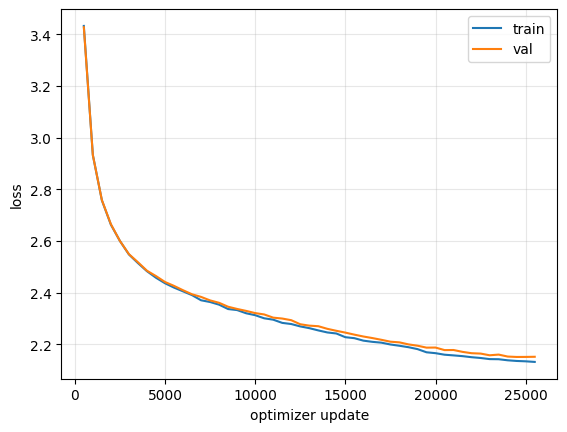

In [ ]:
import matplotlib.pyplot as plt

x = [h["update"] for h in history]
plt.plot(x, [h["train"] for h in history], label="train")
plt.plot(x, [h["val"] for h in history], label="val")
plt.xlabel("optimizer update"); plt.ylabel("loss"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

## STEP 10: GENERATE (HOPEFULLY) VIRAL STORIES!!!

In [ ]:
model.load_state_dict(torch.load(BEST, map_location=device)) # loads the checkpoint containing the best weights recorded onto gpu, cpu, or mps
model.eval() # swtich layers like dropout to evaluation mode during inference

@torch.no_grad() # disables gradient tracking during inference
def write_stories(n = 5, max_new_tokens=600, temperature=0.8, top_k=200, prompt=None):
    ids = [eot_id] + (enc.encode_ordinary(prompt) if prompt else []) # model was trained with <|endoftext|>, so keeping it at beginning signals model that we are generating a new story
    idx = torch.tensor([ids] * n, dtype=torch.int64, device=device) # creates n rows in B dimension, to generate independent stories
    done = torch.zeros(n, dtype=torch.bool, device=device) # creates a boolean tensor of flags indicating which of the n stories produced <|endoftext|> token

    for _ in range(max_new_tokens):
        logits, _ = model(idx[:, -config.block_size:]) # ensures the context passed into the model never exceeds maximum context window of 512. so keep only most recent tokens
        logits = logits[:, -1, :] / temperature # temp <1.0 sharpens tokens to most likely (more COHERENT STORIES), temp >1.0 flattens distribution (creating randomness)
        v, _ = torch.topk(logits, min(top_k, logits.size(-1))) # truncate sampling pool to top_k most probable words, setting the rest to -inf
        logits[logits < v[:, [-1]]] = float("-inf")
        nxt = torch.multinomial(F.softmax(logits, dim=-1), num_samples=1) # sample next tokenID
        nxt = torch.where(done.unsqueeze(1), torch.full_like(nxt, eot_id), nxt) # id story stream already finished, force any further generated tokens to remain <|endoftext|>
        done |= nxt.squeeze(1) == eot_id # mark a story as finished when it samples eot_id
        idx = torch.cat((idx, nxt), dim=1) # append newly sampled tokenID to the right of existing sequence.
        if bool(done.all()): break # early exit as soon as every story in the batch_limit emits <|endoftext|>

    for row in idx.tolist():
        out = row[1:] # strip off the leading <|endoftext|> manually injected
        ended = eot_id in out
        if ended: out = out[:out.index(eot_id)] # detects whether model produced an end token. if so, truncate the token list at that exact index to remove trailining padding tokens
        text = enc.decode(out).strip() # convert the array of token IDs back into human readable text via GPT-2 TikToken tokenizer
        print(f"=== {len(text.split())} words, {'complete' if ended else 'TRUNCATED'} ===") # print if story naturally ended or was truncated
        print(text)
        print()

write_stories(5) #


=== 231 words, complete ===
The shrill ring of my phone, a stark white intrusion in the quiet of our lake house, jolted me from my quiet routine. My foster parents, their voices tight with an unspoken urgency, explained that my father had secured a massive, unexpected inheritance from a distant relative, and I, the younger one, was expected to manage it immediately.

I found them in the antique den, amidst the dusty relics of a stranger’s life, the air thick with the scent of pine and something vaguely metallic. My sister, their only child, hovered in the doorway, her eyes darting towards the door, a faint tremor in her hand as she confessed a substantial portion of my father’s fortune had vanished. I felt a cold knot of dread tighten in my stomach; this wasn't just a mistake, it was a calculated move.

I gathered my younger siblings, their faces pale but resolute, and waited for the inevitable confrontation. We presented our documents, the proof of my father’s deliberate exploitation,

## Save Before Session Dies

In [ ]:
for f in sorted(os.listdir(OUT_DIR)):
    print(f"  {f:28s} {os.path.getsize(OUT_DIR + '/' + f)/1e6:8.2f} MB")

# Colab: from google.colab import files; files.download(BEST)

  best_model_params.pt           204.89 MB
  ckpt.pt                        614.69 MB
  train.bin                     1677.28 MB
  val.bin                         16.93 MB


In [ ]:
import os
d = "/content/drive/MyDrive/yt-ai-slm"
for f in sorted(os.listdir(d)):
    print(f"{f:28s} {os.path.getsize(os.path.join(d,f))/1e6:8.1f} MB")


best_model_params.pt            204.9 MB
ckpt.pt                         614.7 MB
